# analysis
Make sky maps and calculate significance

Author: Nik Korzoun

# Imports

In [199]:
# imports
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.patches import Circle
import numpy as np
import astropy.units as u
from astropy import wcs
from astropy.coordinates import SkyCoord
from scipy.stats import norm

# Globals

In [200]:
# analysis cuts
MIN_NPIX = 3 # minimum number of pixels in an image
MIN_TEL = 2 # cut on the minimum number of telescopes in an event
TELESCOPES = ["Fern", "Heli", "Winter"] # restrict analysis to these telescopes
# THETA = 0.32214
THETA = 0.2 # used for on/off region radius and theta square cut
MAX_DISTANCE = 2 # max distance cut
WIDTH = True # cut is based on mean/sdev of per-telescope distribution
WIDTH_CUT_NSIGMA = -0.5 # width cut threshold: per-telescope (mean + WIDTH_CUT_NSIGMA*std)

# plotting
PLOT_RADIUS = 2  # degrees from center; controls extent of all sky-position plots below
BIN_WIDTH = 0.05
CBAR_VMIN = -5  # fixed range for the significance map and significance distribution
CBAR_VMAX = 5

In [201]:
TEL_NAME = {
  1: "Heli",
  2: "Fern",
  3: "Winter"
}

# Data files

In [202]:
import glob

files=glob.glob("data/**/*.csv")
# files=glob.glob("data/20260115/*.csv")

files=[f for f in files if "Crab" in f]
# files=[f for f in files if ".uncorrected" in f]
files=[f for f in files if ".corrected" in f]
# files=[f for f in files if ".gaincorrected" in f]
# files=[f for f in files if "preflip" in f]
# files=[f for f in files if "postflip" in f]


files = sorted(files)

buffer=0
list=[]
for f in files:
    temp = pd.read_csv(f)
    temp["File"]=f[36:-16]
    temp["In-file-Index"]=temp["Event"]
    temp["Event"]=temp["Event"]+buffer
    buffer+=len(temp)
    list.append(temp)

df = pd.concat(list, ignore_index=True)

In [203]:
files

['data/20260113/Crab_postflip.root.corrected.csv',
 'data/20260113/Crab_preflip.root.corrected.csv',
 'data/20260114/Crab_postflip.root.corrected.csv',
 'data/20260114/Crab_preflip.root.corrected.csv',
 'data/20260115/Crab_postflip.root.corrected.csv',
 'data/20260115/Crab_preflip.root.corrected.csv',
 'data/20260116/Crab_postflip.root.corrected.csv',
 'data/20260117/Crab_postflip.root.corrected.csv',
 'data/20260118/Crab_postflip.root.corrected.csv',
 'data/20260119/Crab_postflip.root.corrected.csv',
 'data/20260119/Crab_preflip.root.corrected.csv',
 'data/20260120/Crab_postflip.root.corrected.csv',
 'data/20260120/Crab_preflip.root.corrected.csv',
 'data/20260121/Crab_postflip.root.corrected.csv',
 'data/20260121/Crab_preflip.root.corrected.csv']

## Cleaning data

In [204]:
# remove nans and duplicates
array=df.dropna(subset=["Length", "Width","Miss","Distance","Azwidth","Alpha"])
array=array.drop_duplicates(subset=array.drop(["Telescope","Event", "In-file-Index"], axis=1))
array=array[array["Width"]>0]

# cut by number of telescopes
array = array.groupby('Event', group_keys=False).filter(lambda x: len(x) > (MIN_TEL-1))

# cut by minimum number of pixels in image
array = array[array.Npix>=MIN_NPIX]

# cut by telescope
array = array[array.Telescope.map(TEL_NAME).isin(TELESCOPES)]

# width cut: per-telescope (mean + WIDTH_CUT_NSIGMA*std)
if WIDTH:
    width_cut_stats = array.groupby('Telescope')['Width'].agg(['mean', 'std'])
    width_cut_stats['cut'] = width_cut_stats['mean'] + WIDTH_CUT_NSIGMA*width_cut_stats['std']
    array = array.merge(width_cut_stats[['cut']], on='Telescope')
    array = array[array.Width < array.cut]
    array = array.drop(columns=['cut'])

array.head()

,Event,Telescope,Timestamp,MeanX,StdX,MeanY,StdY,Phi,Size,Npix,Length,Width,Miss,Distance,Azwidth,Alpha,File,In-file-Index
3,75,3,1.768284e+09,2.446748,0.299177,0.404754,0.526997,68.839443,512.008212,17,0.557581,0.237350,2.135661,2.480001,0.495090,59.446330,,75
19,117,2,1.768284e+09,-1.750625,0.330188,1.840888,0.258636,346.055380,871.481131,16,0.334354,0.253228,1.364763,2.540385,0.279073,32.495066,,117
22,119,2,1.768284e+09,5.053853,0.306772,0.780255,0.490440,70.049323,635.447202,20,0.512595,0.268118,4.484323,5.113730,0.467611,61.272828,,119
31,150,3,1.768284e+09,-2.195189,0.312229,-0.577474,0.500036,286.321849,1273.646670,24,0.514145,0.288407,2.269008,2.269875,0.514010,88.416664,,150
32,153,1,1.768284e+09,1.840547,0.518223,-3.048620,0.413380,322.961989,617.497792,16,0.630647,0.204259,1.324875,3.561137,0.301655,21.841299,,153


In [205]:
array.describe()

,Event,Telescope,Timestamp,MeanX,StdX,MeanY,StdY,Phi,Size,Npix,Length,Width,Miss,Distance,Azwidth,Alpha,In-file-Index
count,21452.000000,21452.000000,2.145200e+04,21452.000000,21452.000000,21452.000000,21452.000000,21452.000000,21452.000000,21452.000000,21452.000000,21452.000000,21452.000000,21452.000000,21452.000000,21452.000000,21452.000000
mean,239722.574492,1.989978,1.768630e+09,0.578841,0.416499,-0.295949,0.417671,181.788328,722.368985,14.477112,0.570710,0.213042,2.252469,3.562661,0.407976,43.381150,5937.576823
std,134012.702304,0.786963,2.355887e+05,2.716090,0.344970,2.685220,0.347542,137.700631,747.126469,7.773715,0.462448,0.052488,1.586528,1.522192,0.325282,25.693676,3463.550287
min,75.000000,1.000000,1.768275e+09,-4.728898,0.059355,-5.644155,0.067756,0.019506,44.033449,3.000000,0.101814,0.053038,0.000339,0.035950,0.067630,0.007882,4.000000
25%,118794.000000,1.000000,1.768381e+09,-1.565616,0.239904,-2.366773,0.240284,45.757321,332.702522,9.000000,0.334427,0.177410,0.882393,2.387427,0.244914,20.879915,2895.750000
50%,253754.000000,2.000000,1.768634e+09,0.644791,0.314645,-0.411575,0.315931,270.789310,542.486822,13.000000,0.432512,0.211388,1.969465,3.607611,0.316132,43.279854,5977.500000
75%,356847.500000,3.000000,1.768878e+09,2.733865,0.450248,1.920554,0.453416,315.335656,866.239905,18.000000,0.600813,0.259402,3.523451,4.730636,0.441327,64.719963,8924.250000
max,461713.000000,3.000000,1.768984e+09,5.553550,4.554813,7.092964,4.224620,359.992849,19956.612980,85.000000,5.295163,0.297274,7.217341,8.367927,4.518258,89.997214,12872.000000


In [206]:
array.Event.nunique()

16738

In [207]:
array.head(100)

,Event,Telescope,Timestamp,MeanX,StdX,MeanY,StdY,Phi,Size,Npix,Length,Width,Miss,Distance,Azwidth,Alpha,File,In-file-Index
3,75,3,1.768284e+09,2.446748,0.299177,0.404754,0.526997,68.839443,512.008212,17,0.557581,0.237350,2.135661,2.480001,0.495090,59.446330,,75
19,117,2,1.768284e+09,-1.750625,0.330188,1.840888,0.258636,346.055380,871.481131,16,0.334354,0.253228,1.364763,2.540385,0.279073,32.495066,,117
22,119,2,1.768284e+09,5.053853,0.306772,0.780255,0.490440,70.049323,635.447202,20,0.512595,0.268118,4.484323,5.113730,0.467611,61.272828,,119
31,150,3,1.768284e+09,-2.195189,0.312229,-0.577474,0.500036,286.321849,1273.646670,24,0.514145,0.288407,2.269008,2.269875,0.514010,88.416664,,150
32,153,1,1.768284e+09,1.840547,0.518223,-3.048620,0.413380,322.961989,617.497792,16,0.630647,0.204259,1.324875,3.561137,0.301655,21.841299,,153
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430,1324,2,1.768285e+09,-2.989780,0.722049,4.669531,0.286104,353.220857,784.102642,30,0.726398,0.274875,4.283963,5.544664,0.587740,50.590476,,1324
433,1349,1,1.768285e+09,3.460083,0.277521,3.300493,0.344222,306.496455,340.192720,7,0.410665,0.163892,4.744582,4.781780,0.407981,82.848727,,1349
434,1349,3,1.768285e+09,4.610273,0.290074,3.188773,0.405346,85.526053,944.862852,19,0.405954,0.289221,4.347482,5.605612,0.363950,50.855731,,1349
438,1363,2,1.768285e+09,2.440672,0.368621,3.567909,0.373281,314.198801,528.081053,19,0.446574,0.275303,4.237147,4.322830,0.441108,78.573354,,1363


# Arrival Directions

In [208]:
event_list = array.drop_duplicates(subset='Event').Event.to_numpy()

Shower_Xoffset = []
Shower_Yoffset = []
file = []
in_file_index = []
event_ids = []
for e in event_list:

    event=array[array.Event == e]
    NTel = len(event)
    
    # check that there are enough images
    if NTel < 2:
        continue # skips to next iteration in for loop
        
    
    m = []
    x = []
    y = []
    s = []
    l = []

    # get relevant image parameters1.2
    for t in range(NTel):
        tel=event.iloc[t]

        s.append(tel.Size)
        x.append(tel.MeanX)
        y.append(tel.MeanY)
        phi_rad = tel.Phi * np.pi/180
        m.append(np.tan(phi_rad))
        if(tel.Length > 0):
            l.append(tel.Width/tel.Length)
        else:
            l.append(1)

    # don't do anything if angle between image axis is too small (for 2 images only)
    fiangdiff = 0
    if NTel == 2:
        fiangdiff = -1*np.abs(np.arctan(m[0]) - np.arctan(m[1])) * 180/np.pi

    # direction reconstruction
    itotweight = 0.
    iweight = 1.
    ixs = 0.
    iys = 0.
    iangdiff = 0.
    b1 = 0.
    b2 = 0.
    v_xs = []
    v_ys = []
    fmean_iangdiff = 0.
    fmean_iangdiffN = 0.

    for i in range(NTel):
        for j in range(NTel):
            if i >= j:
                continue

            # check minimum angle between image lines; ignore if too small
            iangdiff = np.abs( np.arctan( m[j] ) - np.arctan( m[i] ) )
            if( iangdiff < 0 or np.abs(np.pi - iangdiff ) < 0 ):
                continue
            
            # mean angle between images
            if( iangdiff < np.pi/2 ):
                fmean_iangdiff += iangdiff * 180/np.pi
            else:
                fmean_iangdiff += ( 180 - (iangdiff * 180/np.pi))
            fmean_iangdiffN += 1
            
            # weight is sin of angle between image lines
            iangdiff = np.abs( np.sin( np.abs( np.arctan( m[j] ) - np.arctan( m[i] ) ) ) )
            
            b1 = y[i] - m[i] * x[i]
            b2 = y[j] - m[j] * x[j]
            
            # line intersection
            if( m[i] != m[j] ):
                xs = ( b2 - b1 )  / ( m[i] - m[j] )
            else:
                xs = 0.
        
            ys = m[i] * xs + b1

            iweight  = 1. / ( 1. / s[i] + 1. / s[j] ) # weight 1: size of images
            iweight *= ( 1. - l[i] ) * ( 1. - l[j] ) # weight 2: elongation of images (width/length)
            iweight *= iangdiff                      # weight 3: angular differences between the two image axis
            iweight *= iweight                       # use squared value

            ixs += xs * iweight
            iys += ys * iweight
            itotweight += iweight
            
            v_xs.append( xs )
            v_ys.append( ys )

    # average difference between image pairs
    if( fmean_iangdiffN > 0. ):
        fmean_iangdiff /= fmean_iangdiffN
    else:
        fmean_iangdiff = 0.

    if( NTel > 2 ):
        fiangdiff = fmean_iangdiff  
	
	# check validity of weight
    if( itotweight > 0. ):

        ixs /= itotweight
        iys /= itotweight
        Shower_Xoffset.append(ixs)
        Shower_Yoffset.append(iys)
        file.append(event.iloc[0].File)
        in_file_index.append(event["In-file-Index"].iloc[0])
        event_ids.append(e)
	
    else:

        print("Image weights invalid")
        print(e)
        # Shower_Xoffset.append(np.nan)
        # Shower_Yoffset.append(np.nan)

In [209]:
directions=pd.DataFrame()
directions['Event'] = event_ids
directions['File'] = file
directions['In-file-Index'] = in_file_index
directions['Xoffset'] = Shower_Xoffset
directions['Yoffset'] = Shower_Yoffset
directions.describe()

,Event,In-file-Index,Xoffset,Yoffset
count,4513.000000,4513.000000,4513.000000,4513.000000
mean,239049.763793,6158.871704,0.796083,-0.372095
std,132511.760254,3502.602057,23.849609,10.979994
min,425.000000,5.000000,-370.941275,-535.455487
25%,119667.000000,3069.000000,-1.527337,-2.351083
50%,254633.000000,6327.000000,0.590921,-0.259398
75%,357505.000000,9171.000000,2.566569,1.966847
max,461713.000000,12872.000000,1436.068304,152.810212


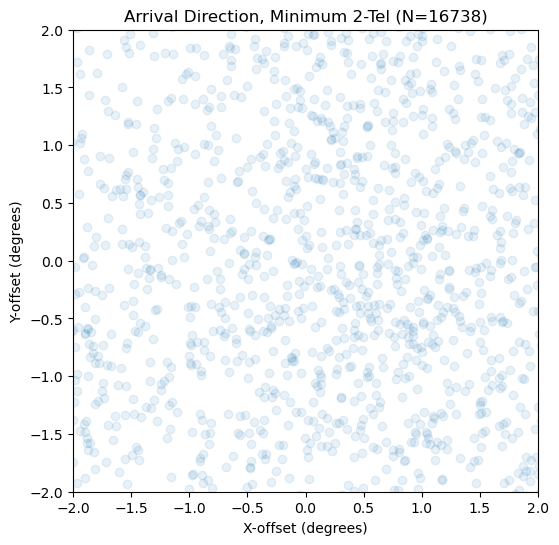

In [210]:
fig,axs = plt.subplots(figsize=(6,6))
plt.xlabel('X-offset (degrees)')
plt.ylabel('Y-offset (degrees)')
axs.set(xlim=[-PLOT_RADIUS,PLOT_RADIUS],ylim=[-PLOT_RADIUS,PLOT_RADIUS],title='Arrival Direction, Minimum {:.0f}-Tel (N={:.0f})'.format(MIN_TEL,len(event_list)))
axs.scatter(directions.Xoffset,directions.Yoffset,alpha=0.1)

### Convert to RA/DEC

In [211]:
# pointing
center=SkyCoord('05 34 31.78 +22 01 02.6', unit=(u.hourangle, u.deg))

# center=SkyCoord('05 44 32 +22 01 03', unit=(u.hourangle, u.deg))
# center=SkyCoord('11 04 19 +38 11 41', unit=(u.hourangle, u.deg))
# center=SkyCoord('22 28 44 +61 10 00', unit=(u.hourangle, u.deg))


# Create a WCS object with tangent projection
w = wcs.WCS(naxis=2)
w.wcs.crpix = [0,0]
w.wcs.crval = [center.ra.deg,center.dec.deg]
w.wcs.cdelt = [-1,1]
w.wcs.ctype = ["RA---TAN", "DEC--TAN"]

# Convert
directions['RA'],directions['DEC'] = w.wcs_pix2world(directions.Yoffset,directions.Xoffset,1)

In [212]:
w

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 83.63241666666664 22.01738888888889 
CRPIX : 0.0 0.0 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : -1.0 1.0 
NAXIS : 0  0

In [213]:
directions.describe()

,Event,In-file-Index,Xoffset,Yoffset,RA,DEC
count,4513.000000,4513.000000,4513.000000,4513.000000,4513.000000,4513.000000
mean,239049.763793,6158.871704,0.796083,-0.372095,83.961440,22.427621
std,132511.760254,3502.602057,23.849609,10.979994,6.280606,4.799762
min,425.000000,5.000000,-370.941275,-535.455487,14.483006,-59.046247
25%,119667.000000,3069.000000,-1.527337,-2.351083,81.495389,20.459542
50%,254633.000000,6327.000000,0.590921,-0.259398,83.913853,22.570889
75%,357505.000000,9171.000000,2.566569,1.966847,86.184405,24.547412
max,461713.000000,12872.000000,1436.068304,152.810212,237.484015,75.649224


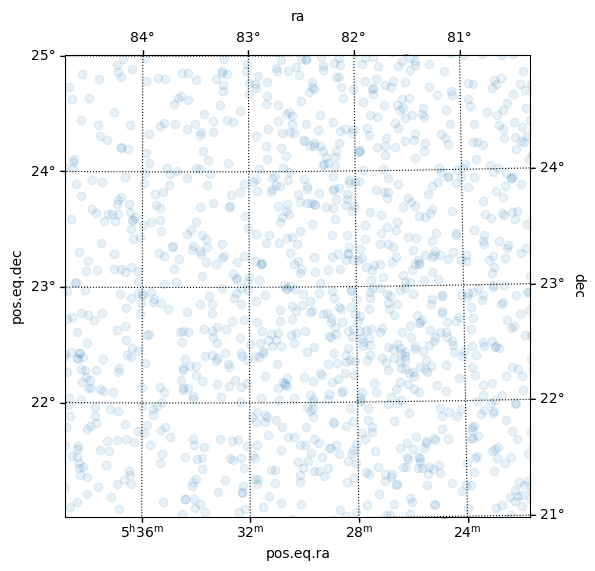

In [214]:

fig=plt.figure(figsize=(6,6))
ax = plt.subplot(projection=w)
ax.set_xlim(-PLOT_RADIUS,PLOT_RADIUS)
ax.set_ylim(-PLOT_RADIUS,PLOT_RADIUS)
ax.scatter(directions.Xoffset,directions.Yoffset,alpha=0.1)

overlay = ax.get_coords_overlay('icrs')
overlay.grid(color='black', ls='dotted')

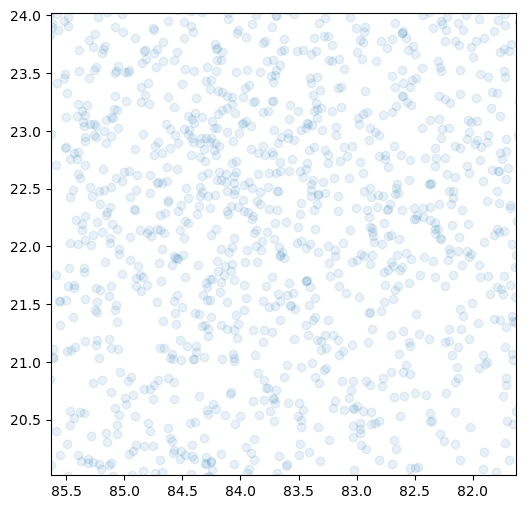

In [215]:
fig=plt.figure(figsize=(6,6))
ax = plt.subplot()
ax.set_xlim(center.ra.deg-PLOT_RADIUS,center.ra.deg+PLOT_RADIUS)
ax.set_ylim(center.dec.deg-PLOT_RADIUS,center.dec.deg+PLOT_RADIUS)
ax.scatter(directions.RA,directions.DEC,alpha=0.1)
plt.gca().invert_xaxis()


In [216]:
directions.describe()

,Event,In-file-Index,Xoffset,Yoffset,RA,DEC
count,4513.000000,4513.000000,4513.000000,4513.000000,4513.000000,4513.000000
mean,239049.763793,6158.871704,0.796083,-0.372095,83.961440,22.427621
std,132511.760254,3502.602057,23.849609,10.979994,6.280606,4.799762
min,425.000000,5.000000,-370.941275,-535.455487,14.483006,-59.046247
25%,119667.000000,3069.000000,-1.527337,-2.351083,81.495389,20.459542
50%,254633.000000,6327.000000,0.590921,-0.259398,83.913853,22.570889
75%,357505.000000,9171.000000,2.566569,1.966847,86.184405,24.547412
max,461713.000000,12872.000000,1436.068304,152.810212,237.484015,75.649224


# Counts Map

In [217]:
n_bins = int(2*PLOT_RADIUS / BIN_WIDTH)
bins_RA = np.linspace(center.ra.deg-PLOT_RADIUS, center.ra.deg+PLOT_RADIUS, n_bins)  
bins_DEC = np.linspace(center.dec.deg-PLOT_RADIUS, center.dec.deg+PLOT_RADIUS, n_bins)

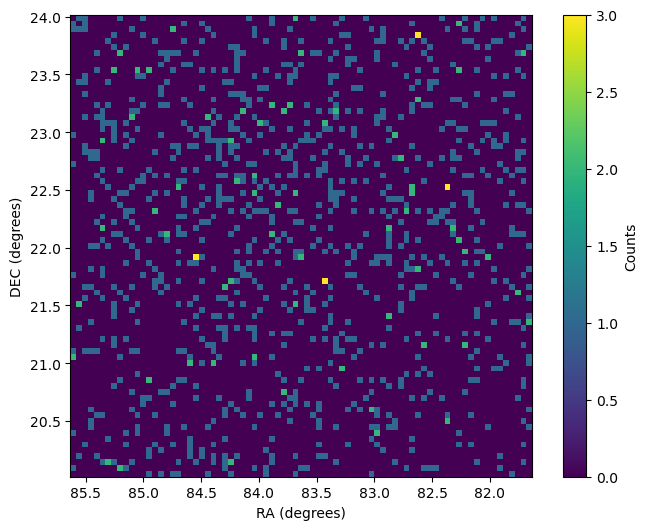

In [218]:
fig, ax = plt.subplots(figsize=(8, 6))

hist = ax.hist2d(directions.RA, directions.DEC, bins=[bins_RA, bins_DEC], cmap='viridis')

ax.invert_xaxis()
ax.set_aspect('equal')
ax.set_xlabel('RA (degrees)')
ax.set_ylabel('DEC (degrees)')

cbar = fig.colorbar(hist[3], ax=ax, label='Counts')

plt.show()


# Correlated (On) Counts Map

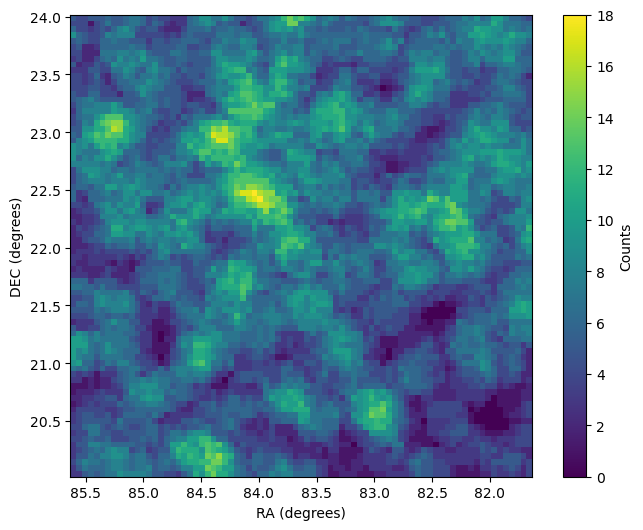

In [219]:
data=pd.DataFrame(columns=['testPosX','testPosY','Counts'])

for x in bins_RA:
    x=x+BIN_WIDTH/2 #bin center
    for y in bins_DEC:
        y=y+BIN_WIDTH/2 #bin center

        # distance
        tmp = array.copy()
        mx, my = w.wcs_pix2world(tmp.MeanY, tmp.MeanX, 1)
        tmp['Distance'] = np.hypot(mx - x, my - y)

        # max distance
        max_mask = tmp.groupby('Event')['Distance'].transform('max') == tmp['Distance']
        max_distance = tmp.loc[max_mask].groupby('Event')['Distance'].max()
        counts_map = directions.copy()
        counts_map = counts_map.join(max_distance, on='Event')

        # calc theta squared
        angle = np.hypot(counts_map.RA - x, counts_map.DEC - y)
        sqr = angle*angle
        counts_map['ThetaSquare'] = sqr.values

        # apply cuts
        counts_map = counts_map[counts_map['Distance'] < MAX_DISTANCE]
        counts_map = counts_map[counts_map['ThetaSquare'] < THETA**2]

        counts=len(counts_map)
        data.loc[-1]=[x,y,counts]
        data.index = data.index + 1


fig, ax = plt.subplots(figsize=(8, 6))

hist = ax.hist2d(data.testPosX, data.testPosY, weights=data.Counts, bins=[bins_RA, bins_DEC], cmap='viridis')

ax.invert_xaxis()
ax.set_aspect('equal')
ax.set_xlabel('RA (degrees)')
ax.set_ylabel('DEC (degrees)')

cbar = fig.colorbar(hist[3], ax=ax, label='Counts')

plt.show()

In [220]:
data.describe()

,testPosX,testPosY,Counts
count,6400.000000,6400.000000,6400.000000
mean,83.657417,22.042389,6.213125
std,1.169317,1.169317,2.774127
min,81.657417,20.042389,0.000000
25%,82.657417,21.042389,4.000000
50%,83.657417,22.042389,6.000000
75%,84.657417,23.042389,8.000000
max,85.657417,24.042389,18.000000


## Define On/Off Regions

In [221]:
Crab=SkyCoord('05 34 31.78 +22 01 02.6', unit=(u.hourangle, u.deg))
HAWC=SkyCoord('05 43 07.20 +23 24 00.0', unit=(u.hourangle, u.deg))
MRK421=SkyCoord('11 04 19 +38 11 41', unit=(u.hourangle, u.deg))
Boomerang=SkyCoord('22 28 44 +61 10 00', unit=(u.hourangle, u.deg))

# testPosX=MRK421.ra.deg
# testPosY=MRK421.dec.deg

testPosX=Crab.ra.deg
testPosY=Crab.dec.deg

# testPosX=85
# testPosY=25

# testPosX=HAWC.ra.deg
# testPosY=HAWC.dec.deg

# testPosX=Boomerang.ra.deg
# testPosY=Boomerang.dec.deg

In [222]:
on_region=(testPosX,testPosY)

Fill camera with off regions

In [223]:
# def make_off_regions(testPosX,testPosY):
#     n_circ=0
#     off_regions=[]
#     skip=4
#     for i in range(2,len(bins_RA)-1,skip):
#         for j in range(2,len(bins_DEC)-1,skip):
#             # Calculate the center of each bin
#             center_x = (bins_RA[i] + bins_RA[i+1]) / 2
#             center_y = (bins_DEC[j] + bins_DEC[j+1]) / 2
            
#             buffer=1.4
#             if (center_x<testPosX-buffer or center_x>testPosX+buffer or center_y<testPosY-buffer or center_y>testPosY+buffer ):
#                 n_circ=n_circ+1
#                 off_regions.append((center_x,center_y))

#     return off_regions

Restrict off regions to vicinity of on region

In [224]:
def make_off_regions(testPosX,testPosY):
    off_regions=[]
    spacing = 2*THETA
    buffer = 4*THETA
    limit = 4*THETA

    r_start = max(buffer, spacing)  # first ring can't be closer than one circle-width out
    n_rings = int(np.floor((limit - r_start) / spacing)) + 1

    for k in range(n_rings):
        r = r_start + k*spacing
        n_points = max(1, int(np.floor(2*np.pi*r / spacing)))
        for p in range(n_points):
            angle = 2*np.pi*p/n_points
            center_x = testPosX + r*np.cos(angle)
            center_y = testPosY + r*np.sin(angle)
            off_regions.append((center_x,center_y))

    return off_regions

Text(0, 0.5, 'DEC (degrees)')

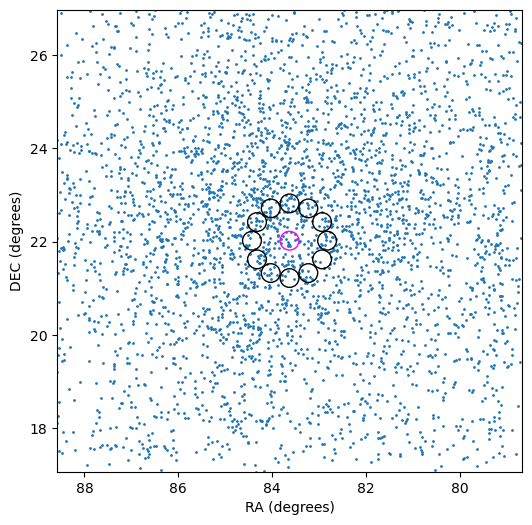

In [225]:
# scatter plot w/ on/off regions

fig=plt.figure(figsize=(6,6))
ax = plt.subplot()
ax.set_xlim(center.ra.deg-4.95,center.ra.deg+4.95)
ax.set_ylim(center.dec.deg-4.95,center.dec.deg+4.95)
ax.scatter(directions.RA,directions.DEC,alpha=1,s=1)
plt.gca().invert_xaxis()

off_regions=make_off_regions(*on_region)

for region in off_regions:
    circ = Circle(region, THETA, facecolor='None', edgecolor='black', lw=1)
    ax.add_patch(circ)
ax.add_patch(Circle(on_region,THETA,facecolor='None',edgecolor='magenta', lw=1))
plt.xlabel('RA (degrees)')
plt.ylabel('DEC (degrees)')

Text(0, 0.5, 'DEC (degrees)')

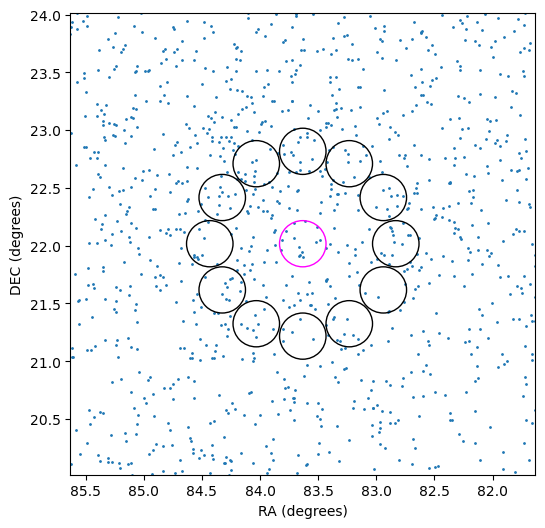

In [226]:
# scatter plot w/ on/off regions

fig=plt.figure(figsize=(6,6))
ax = plt.subplot()
ax.set_xlim(center.ra.deg-PLOT_RADIUS,center.ra.deg+PLOT_RADIUS)
ax.set_ylim(center.dec.deg-PLOT_RADIUS,center.dec.deg+PLOT_RADIUS)
ax.scatter(directions.RA,directions.DEC,alpha=1,s=1)
plt.gca().invert_xaxis()

off_regions=make_off_regions(*on_region)

for region in off_regions:
    circ = Circle(region, THETA, facecolor='None', edgecolor='black', lw=1)
    ax.add_patch(circ)
ax.add_patch(Circle(on_region,THETA,facecolor='None',edgecolor='magenta', lw=1))
plt.xlabel('RA (degrees)')
plt.ylabel('DEC (degrees)')

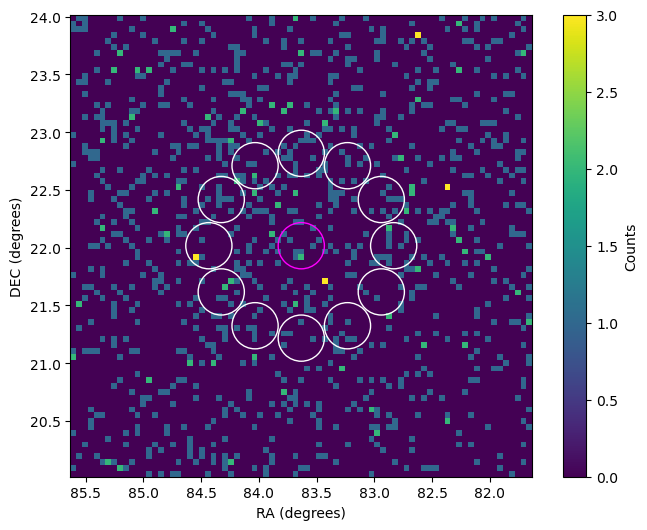

Number of off regions:  12


In [227]:
fig, ax = plt.subplots(figsize=(8, 6))

hist = ax.hist2d(directions.RA, directions.DEC, bins=[bins_RA, bins_DEC], cmap='viridis')

ax.invert_xaxis()
ax.set_aspect('equal')
ax.set_xlabel('RA (degrees)')
ax.set_ylabel('DEC (degrees)')

cbar = fig.colorbar(hist[3], ax=ax, label='Counts')


on_region=(testPosX,testPosY)
off_regions=make_off_regions(*on_region)

for region in off_regions:
    circ = Circle(region, THETA, facecolor='None', edgecolor='white', lw=1)
    ax.add_patch(circ)
ax.add_patch(Circle(on_region,THETA,facecolor='None',edgecolor='magenta', lw=1))

plt.show()            
print('Number of off regions: ',len(off_regions))

# Significance

Li and Ma (9):
$S=\frac{N_{on}-\alpha N_{off}}{\sqrt{\alpha(N_{on}+N_{off})}}$

The code uses Equation 17

In [228]:
# "borrowed" from Eventdisplay VStatistics.h
def significance(Non,Noff,alpha):

    if( alpha == 0. ):
        Sig17 = 0.0
        return Sig17
    
    alphasq = alpha * alpha
    oneplusalpha = 1.0 + alpha
    oneplusalphaoveralpha = oneplusalpha / alpha

    Nsig = Non - alpha * Noff
    Ntot = Non + Noff

    # Sig5
    if( Non + alphasq * Noff > 0. ):
        Sig5 = Nsig / np.sqrt( Non + alphasq* Noff )
    else:
        Sig5 = 0.
    
    # Sig9
    if( alpha * Ntot > 0. ):
        Sig9 = Nsig / np.sqrt( alpha* Ntot )
    else:
        Sig9 = 0.
    
    # Sig17
    if( Ntot == 0. ):
        Sig17 = 0.
    elif( Non == 0 and Noff != 0. ):
        Sig17 = np.sqrt( 2.*( Noff* np.log( oneplusalpha * ( Noff / Ntot ) ) ) )
    elif( Non != 0 and Noff == 0. ):
        Sig17 = np.sqrt( 2.*( Non* np.log( oneplusalphaoveralpha * ( Non / Ntot ) ) ) )
    else:
        Sig17 = 2.*( Non* np.log( oneplusalphaoveralpha * ( Non / Ntot ) ) + Noff* np.log( oneplusalpha * ( Noff / Ntot ) ) )
        # value in brackets can be a small negative number
        if Sig17 > 0.:
            Sig17 = np.sqrt( Sig17 )
        else:
            Sig17 = 0.
            
    
    if( Nsig < 0 ):
        Sig17 = -Sig17
    
    # return Sig5
    # return Sig9
    return Sig17

## $\alpha$

In [229]:
def calc_alpha(off_regions):
    area_B = np.pi*THETA**2
    area_A = len(off_regions) * np.pi * THETA**2
    alpha=area_B/area_A
    return alpha

In [230]:
calc_alpha(off_regions)

0.08333333333333331

## $N_{on}$

In [231]:
def calc_Non(on_region, directions=directions, array=array):

    center_x, center_y = on_region

    # distance
    tmp = array.copy()
    mx, my = w.wcs_pix2world(tmp.MeanY, tmp.MeanX, 1)
    tmp['Distance'] = np.hypot(mx - center_x, my - center_y)

    # max distance
    max_mask = tmp.groupby('Event')['Distance'].transform('max') == tmp['Distance']
    max_distance = tmp.loc[max_mask].groupby('Event')['Distance'].max()
    on = directions.copy()
    on = on.join(max_distance, on='Event')

    # theta square
    angle = np.hypot(on.RA - center_x, on.DEC - center_y)
    sqr = angle*angle
    on['ThetaSquare'] = sqr.values

    on = on[on['Distance'] < MAX_DISTANCE]
    on = on[on['ThetaSquare'] < THETA*THETA]

    return on


In [232]:
on=calc_Non(on_region)

In [233]:
len(on)

13

In [234]:
on.describe()

,Event,In-file-Index,Xoffset,Yoffset,RA,DEC,Distance,ThetaSquare
count,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000
mean,163149.692308,7442.769231,0.007429,-0.028185,83.662829,22.024779,1.425254,0.022665
std,117662.885582,4223.390347,0.103425,0.104867,0.113123,0.103423,0.316049,0.014693
min,11097.000000,993.000000,-0.116673,-0.176598,83.436167,21.900716,0.722622,0.001952
25%,81127.000000,5144.000000,-0.069624,-0.072531,83.629681,21.947765,1.340066,0.009478
50%,118915.000000,6887.000000,-0.027552,-0.028556,83.663197,21.989833,1.404253,0.023429
75%,225047.000000,11097.000000,0.046667,0.002538,83.710679,22.064037,1.631434,0.038239
max,362995.000000,12297.000000,0.194429,0.181979,83.822835,22.211816,1.906313,0.039584


In [235]:
on.head()

,Event,File,In-file-Index,Xoffset,Yoffset,RA,DEC,Distance,ThetaSquare
242,11097,,11097,-0.027552,-0.032021,83.666950,21.989833,1.631434,0.001952
443,44903,,6281,0.108500,-0.132285,83.775217,22.125826,1.843276,0.032151
624,76298,,6887,0.194429,0.020007,83.610806,22.211816,1.010583,0.038269
835,81127,,11716,-0.103147,-0.028556,83.663197,21.914239,1.340066,0.011587
874,81708,,12297,0.032267,-0.168334,83.814033,22.049556,1.519938,0.034019


## $N_{off}$

In [236]:
def calc_Noff(off_regions, directions=directions, array=array):
    off = directions[0:0].copy()

    for (center_x, center_y) in off_regions:

        # reset
        tmp = array.copy()
        counts_map = directions.copy()

        # distance
        mx, my = w.wcs_pix2world(tmp.MeanY, tmp.MeanX, 1)
        tmp['Distance'] = np.hypot(mx - center_x, my - center_y)

        # max distance
        max_mask = tmp.groupby('Event')['Distance'].transform('max') == tmp['Distance']
        max_distance = tmp.loc[max_mask].groupby('Event')['Distance'].max()
        counts_map = counts_map.join(max_distance, on='Event')

        # calc theta square
        angle = np.hypot(counts_map.RA - center_x, counts_map.DEC - center_y)
        sqr = angle*angle
        counts_map['ThetaSquare'] = sqr.values

        counts_map = counts_map[counts_map['Distance'] < MAX_DISTANCE]
        counts_map = counts_map[counts_map['ThetaSquare'] < THETA**2]

        off = pd.concat([off, counts_map])

    return off


In [237]:
off=calc_Noff(off_regions)

In [238]:
len(off)

80

In [239]:
off.describe()

,Event,In-file-Index,Xoffset,Yoffset,RA,DEC,Distance,ThetaSquare
count,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000
mean,224444.962500,6281.250000,0.077767,-0.046683,83.682890,22.094143,1.272054,0.018447
std,130275.483711,3100.409269,0.564435,0.535631,0.577842,0.564484,0.360938,0.011921
min,2422.000000,450.000000,-0.838019,-0.864328,82.705936,21.179123,0.344353,0.000182
25%,115607.750000,3621.000000,-0.433515,-0.505257,83.156064,21.582919,1.035155,0.008376
50%,224268.500000,5954.000000,0.143905,-0.083398,83.722346,22.159555,1.296383,0.016334
75%,312921.500000,8959.250000,0.588485,0.442964,84.176843,22.605066,1.515679,0.027770
max,456245.000000,12489.000000,0.925406,0.858492,84.563919,22.942713,1.984194,0.038411


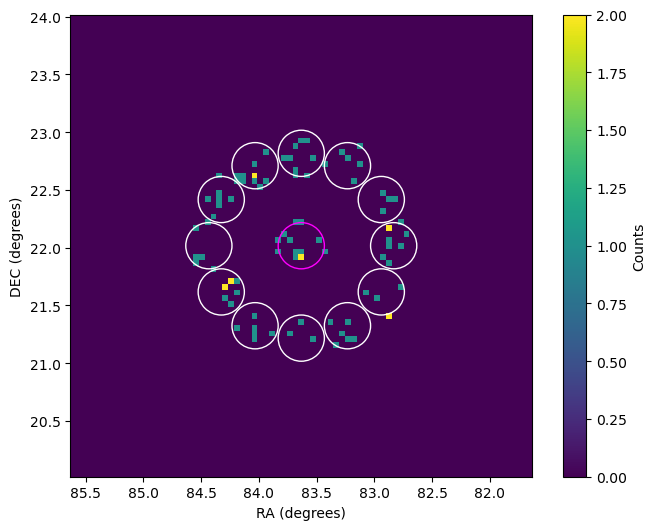

In [240]:
fig, ax = plt.subplots(figsize=(8, 6))
onoff=pd.concat([on,off])

hist = ax.hist2d(onoff.RA, onoff.DEC, bins=[bins_RA, bins_DEC], cmap='viridis')

ax.invert_xaxis()
ax.set_aspect('equal')
ax.set_xlabel('RA (degrees)')
ax.set_ylabel('DEC (degrees)')

cbar = fig.colorbar(hist[3], ax=ax, label='Counts')

circ1 = Circle(on_region, THETA, facecolor='None', edgecolor='magenta', lw=1)
ax.add_patch(circ1)

for region in off_regions:
    circ = Circle((region[0],region[1]), THETA, facecolor='None', edgecolor='white', lw=1)
    ax.add_patch(circ)

## significance

In [241]:
# at test position only
significance(len(on),len(off),calc_alpha(off_regions))

2.0603290118525197

In [242]:
def calc_sigmap():
    sig=pd.DataFrame(columns=['testPosX','testPosY','significance','on','off','alpha'])

    for x in bins_RA:
        x=x+BIN_WIDTH/2 #bin center
        for y in bins_DEC:
            y=y+BIN_WIDTH/2 #bin center

            # define on/off regions
            off_regions=make_off_regions(x,y)
            on=calc_Non(on_region=(x,y))
            off=calc_Noff(off_regions=off_regions)

            # calc significance
            N_on = len(on)
            N_off = len(off)
            alpha = calc_alpha(off_regions)

            sigma=significance(N_on,N_off,alpha)
            sig.loc[-1]=[x,y,sigma,N_on,N_off,alpha]
            sig.index = sig.index + 1

    return sig

In [243]:
sig=calc_sigmap()

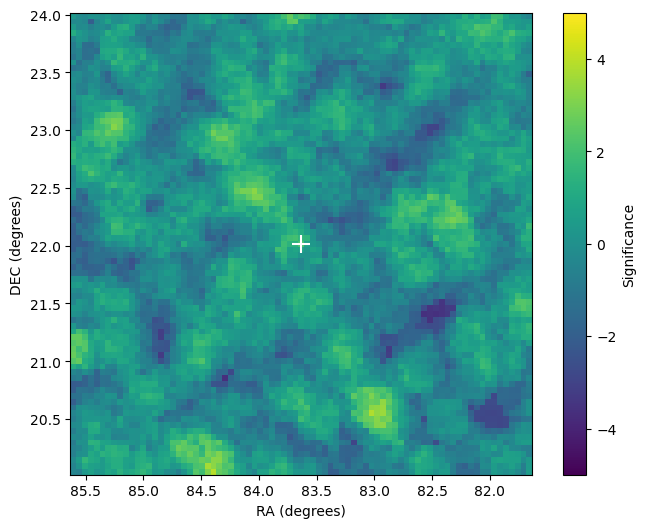

In [244]:
fig, ax = plt.subplots(figsize=(8, 6))

hist = ax.hist2d(sig.testPosX, sig.testPosY, weights=sig.significance, bins=[bins_RA, bins_DEC], cmap='viridis', vmin=CBAR_VMIN, vmax=CBAR_VMAX)

ax.invert_xaxis()
ax.set_aspect('equal')
ax.set_xlabel('RA (degrees)')
ax.set_ylabel('DEC (degrees)')

cbar = fig.colorbar(hist[3], ax=ax, label='Significance')
# circ1 = Circle(on_region, THETA, facecolor='None', edgecolor='magenta', lw=1)
# ax.add_patch(circ1)
ax.scatter(*on_region,marker='+',color='white',s=150)

# plt.savefig('sigmap.png',dpi=300)

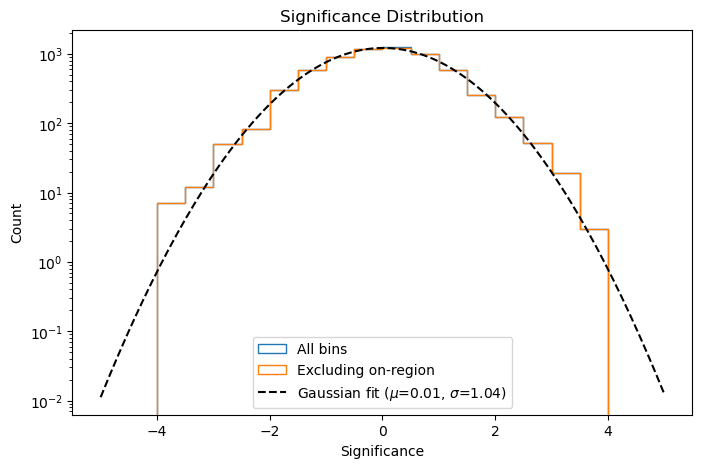

In [245]:
fig, ax = plt.subplots(figsize=(8, 5))

nbins=20
bins = np.linspace(CBAR_VMIN, CBAR_VMAX,nbins+1)

on_mask = np.hypot(sig.testPosX - on_region[0], sig.testPosY - on_region[1]) < THETA
sig_excl = sig[~on_mask]

ax.hist(sig.significance, bins=bins, histtype='step', label='All bins')
ax.hist(sig_excl.significance, bins=bins, histtype='step', label='Excluding on-region')

mu, std = norm.fit(sig_excl.significance)
x = np.linspace(CBAR_VMIN, CBAR_VMAX, 200)
bin_width = bins[1] - bins[0]
p = norm.pdf(x, mu, std) * len(sig_excl.significance) * bin_width
ax.plot(x, p, 'k--', label=f'Gaussian fit ($\\mu$={mu:.2f}, $\\sigma$={std:.2f})')

ax.set_yscale('log')
ax.set_xlabel('Significance')
ax.set_ylabel('Count')
ax.set_title('Significance Distribution')
ax.legend()
plt.show()

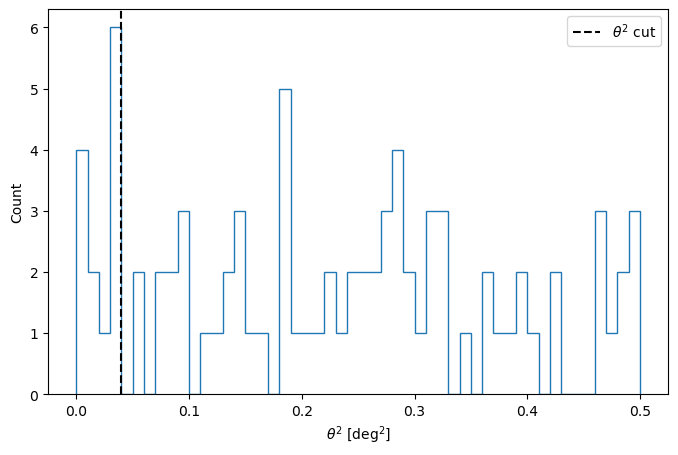

In [246]:
fig, ax = plt.subplots(figsize=(8, 5))

tmp = array.copy()
mx, my = w.wcs_pix2world(tmp.MeanY, tmp.MeanX, 1)
tmp['Distance'] = np.hypot(mx - on_region[0], my - on_region[1])
max_distance = tmp.groupby('Event')['Distance'].max()

directions['ThetaSquare'] = np.hypot(directions.RA - on_region[0], directions.DEC - on_region[1])**2
directions['Distance'] = directions['Event'].map(max_distance)

directions_dcut = directions[directions.Distance < MAX_DISTANCE]

ax.hist(directions_dcut.ThetaSquare, bins=50, range=(0, 0.5), histtype='step')
ax.axvline(THETA**2, color='k', linestyle='--', label=r'$\theta^2$ cut')
ax.set_xlabel(r'$\theta^2$ [deg$^2$]')
ax.set_ylabel('Count')
ax.legend()
plt.show()

# On Map

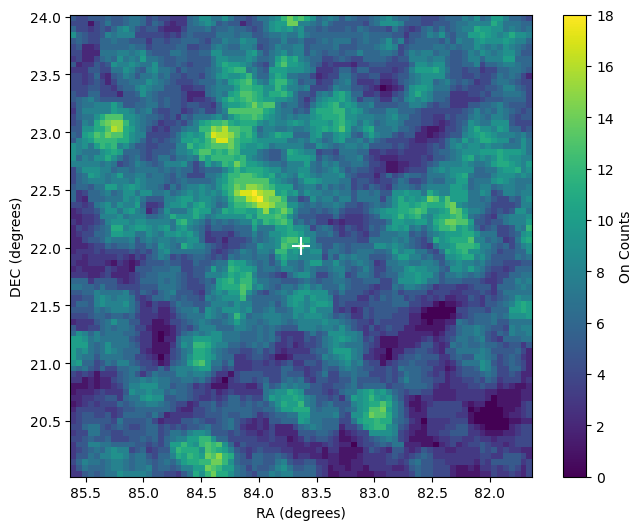

In [247]:
fig, ax = plt.subplots(figsize=(8, 6))

hist = ax.hist2d(sig.testPosX, sig.testPosY,weights=sig.on, bins=[bins_RA, bins_DEC],cmap='viridis')

ax.invert_xaxis()
ax.set_aspect('equal')
ax.set_xlabel('RA (degrees)')
ax.set_ylabel('DEC (degrees)')

cbar = fig.colorbar(hist[3], ax=ax, label='On Counts')
ax.scatter(*on_region, marker='+', color='white', s=150);

# Off Map

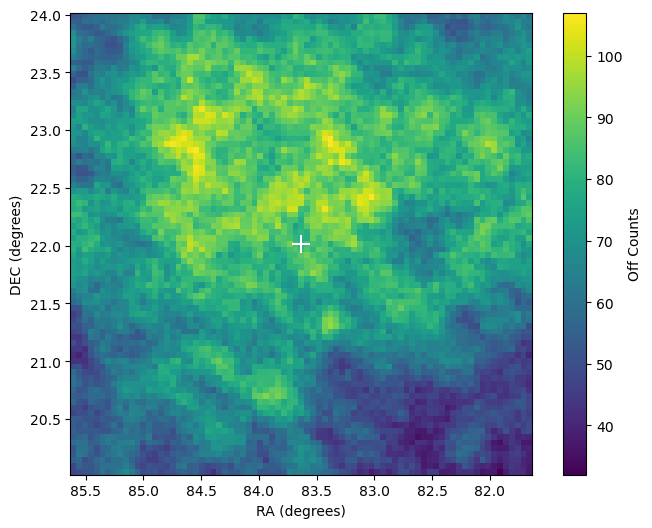

In [248]:
fig, ax = plt.subplots(figsize=(8, 6))

hist = ax.hist2d(sig.testPosX, sig.testPosY,weights=sig.off, bins=[bins_RA, bins_DEC],cmap='viridis')

ax.invert_xaxis()
ax.set_aspect('equal')
ax.set_xlabel('RA (degrees)')
ax.set_ylabel('DEC (degrees)')

cbar = fig.colorbar(hist[3], ax=ax, label='Off Counts')
ax.scatter(*on_region, marker='+', color='white', s=150);

# Alpha Map

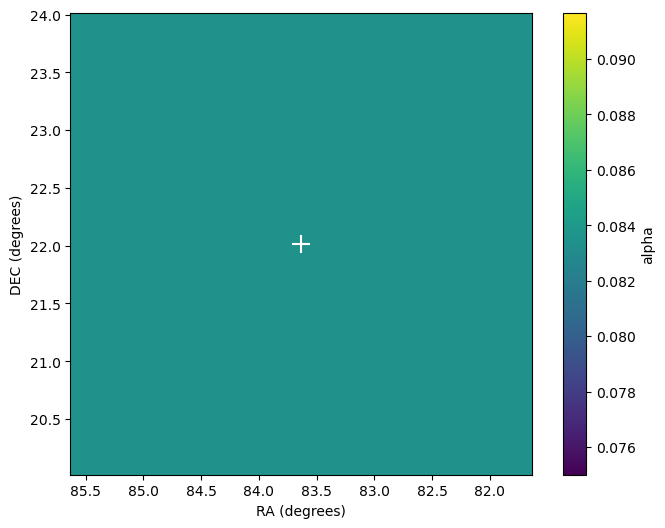

In [249]:
fig, ax = plt.subplots(figsize=(8, 6))

hist = ax.hist2d(sig.testPosX, sig.testPosY,weights=sig.alpha, bins=[bins_RA, bins_DEC],cmap='viridis')

ax.invert_xaxis()
ax.set_aspect('equal')
ax.set_xlabel('RA (degrees)')
ax.set_ylabel('DEC (degrees)')

cbar = fig.colorbar(hist[3], ax=ax, label='alpha')
ax.scatter(*on_region, marker='+', color='white', s=150);

# Excess Map

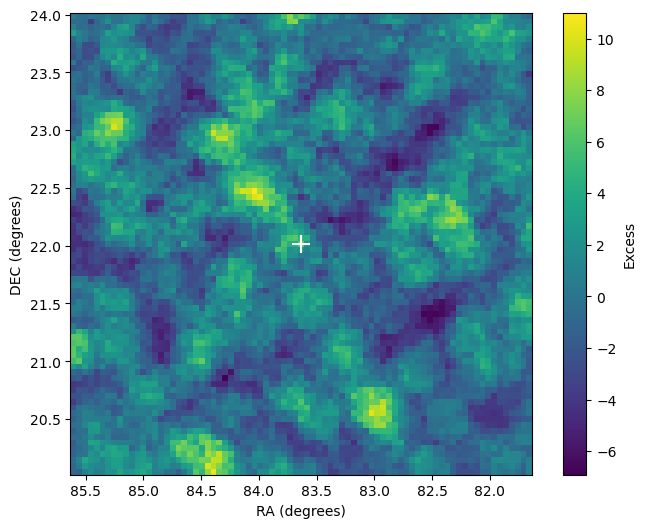

In [250]:
fig, ax = plt.subplots(figsize=(8, 6))

excess=sig.on-sig.alpha*sig.off

hist = ax.hist2d(sig.testPosX, sig.testPosY,weights=excess, bins=[bins_RA, bins_DEC],cmap='viridis')

ax.invert_xaxis()
ax.set_aspect('equal')
ax.set_xlabel('RA (degrees)')
ax.set_ylabel('DEC (degrees)')

cbar = fig.colorbar(hist[3], ax=ax, label='Excess')
ax.scatter(*on_region, marker='+', color='white', s=150);

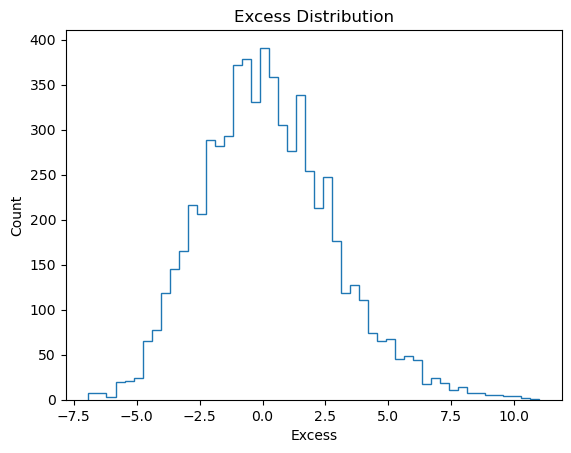

In [251]:
plt.hist(excess, bins=50, histtype='step')
plt.xlabel('Excess')
plt.ylabel('Count')
plt.title('Excess Distribution')
plt.show()

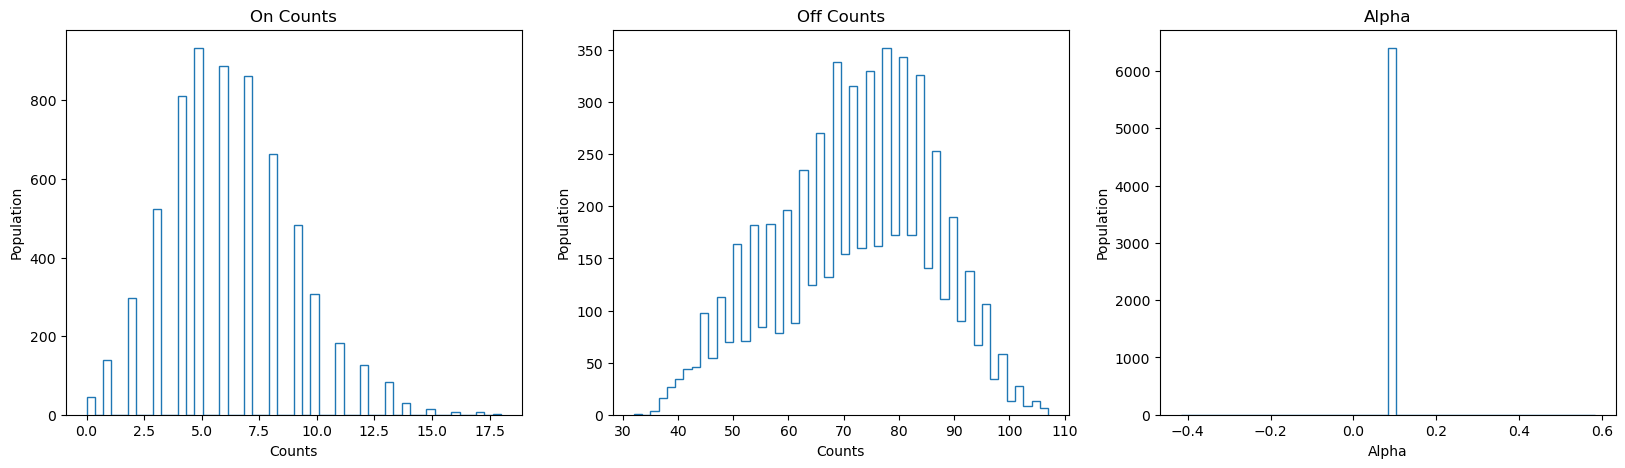

In [252]:
# other distributions
fig, axs = plt.subplots(1,3,figsize=(20, 5))
axs[0].hist(sig.on, bins=50, histtype='step')
axs[0].set_title('On Counts')
axs[0].set_xlabel('Counts')
axs[1].hist(sig.off, bins=50, histtype='step')
axs[1].set_title('Off Counts')
axs[1].set_xlabel('Counts')
axs[2].hist(sig.alpha, bins=50, histtype='step')
axs[2].set_title('Alpha')
axs[2].set_xlabel('Alpha')


for ax in axs:
    ax.set_ylabel('Population')

plt.show()